Accuracy: 0.5706666666666667
Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.62      0.66      2018
           1       0.38      0.48      0.42       982

    accuracy                           0.57      3000
   macro avg       0.54      0.55      0.54      3000
weighted avg       0.60      0.57      0.58      3000



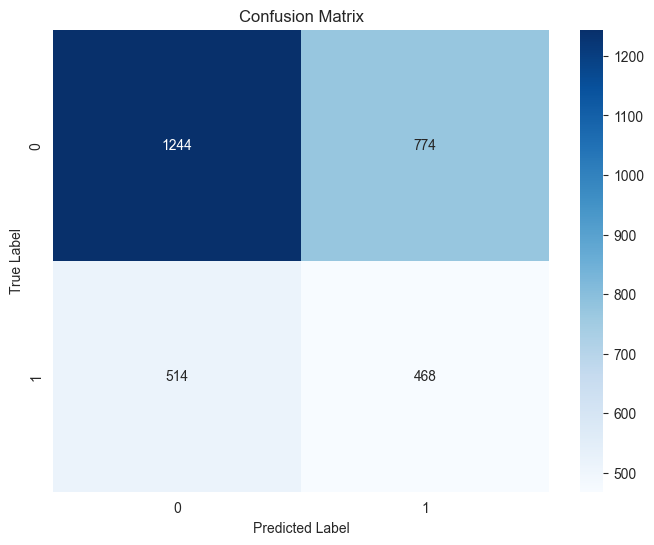

In [5]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE  # Import SMOTE

# Load your dataset (replace this with your actual data loading method)
data = pd.read_csv('data/domestic_violence_fake_data.csv')

# Features and target
x = data.drop("Victim", axis=1)  # Replace with the relevant features
y = data["Victim"]  # Target column (assuming this is the target in your dataset)

# Split the dataset into train and test sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.30, stratify=y)

# Apply SMOTE to balance the training set
smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

# Create the Decision Tree model
clf = DecisionTreeClassifier(random_state=42)
clf.fit(x_train_smote, y_train_smote)

# Make predictions on the test set
y_pred = clf.predict(x_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()
